# Data Analysis: Vehicle Adoption Dataset

In this section, we will load the dataset `McGill_SAAQ_2020_2024-01-10.csv`, perform an initial exploration, and visualize key features to understand the data.

In [ ]:
# Import required libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd
import unicodedata
import re

In [ ]:
# Import required libraries
import pandas as pd

# Load the dataset (try common encodings)
file_path = "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/SAQ data/McGill_SAAQ_2020_2024-01-10.csv"
df = pd.read_csv(file_path, encoding='utf-16', sep=';', low_memory=False)
#df.head()

In [ ]:
df.head()

In [ ]:
# Show basic info and summary statistics
df.info()

In [ ]:
# Show summary statistics for numeric columns
df.describe()

In [ ]:
# Visualize distributions of key numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[numeric_cols].hist(figsize=(15, 8), bins=20, layout=(2, min(4, len(numeric_cols))))
plt.suptitle('Distributions of Numeric Features')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# Visualize categorical features (if any) in subplots
import math

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
n_cols = 5
n = len(categorical_cols)
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten() if n > 1 else [axes]

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# STEP 0 — Clean and prepare key variables
First, clean fuel type and convert numeric columns.

In [ ]:
# Clean decimal comma columns
for col in ['TC', 'TC_ville', 'TC_route', 'TCPP', 'TE']:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(',', '.', regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Standardize fuel type
def classify_fuel(row):
    carb = str(row['CARB']).upper()
    motor = str(row['Motorisation']).upper()

    if 'ELECT' in motor or 'ELEC' in carb:
        return 'Electric'
    if carb == 'H':
        return 'Hybrid'
    if carb == 'D':
        return 'Diesel'
    return 'Gasoline'

df['FuelType'] = df.apply(classify_fuel, axis=1)

# Vehicle age
df['VehicleAge'] = df['AnneeSAAQ'] - df['ANV']

# 1. ADOPTION OVER TIME
A. Fleet share by fuel type per year (stock)

In [ ]:
share_year = (
    df.groupby(['AnneeSAAQ', 'FuelType'])
      .size()
      .reset_index(name='Count')
)

total_year = (
    df.groupby('AnneeSAAQ')
      .size()
      .reset_index(name='Total')
)

share_year = share_year.merge(total_year, on='AnneeSAAQ')
share_year['Share'] = share_year['Count'] / share_year['Total']

for fuel in share_year['FuelType'].unique():
    subset = share_year[share_year['FuelType'] == fuel]
    plt.plot(subset['AnneeSAAQ'], subset['Share'])

plt.xlabel('Year')
plt.ylabel('Fleet Share')
plt.title('Fleet Fuel Share Over Time')
plt.show()

B. Adoption among entrants only (true adoption signal)

In [ ]:
df_new = df[df['Entrant'] == 1]

share_new = (
    df_new.groupby(['AnneeSAAQ', 'FuelType'])
          .size()
          .reset_index(name='Count')
)

total_new = (
    df_new.groupby('AnneeSAAQ')
          .size()
          .reset_index(name='Total')
)

share_new = share_new.merge(total_new, on='AnneeSAAQ')
share_new['Share'] = share_new['Count'] / share_new['Total']

for fuel in share_new['FuelType'].unique():
    subset = share_new[share_new['FuelType'] == fuel]
    plt.plot(subset['AnneeSAAQ'], subset['Share'])

plt.xlabel('Year')
plt.ylabel('Share of New Registrations')
plt.title('Fuel Share Among New Vehicles')
plt.show()

# 2. SPATIAL DISTRIBUTION

A. EV share by region in latest year

In [ ]:
latest_year = df['AnneeSAAQ'].max()
df_latest = df[df['AnneeSAAQ'] == latest_year]

region_share = (
    df_latest.groupby(['Region', 'FuelType'])
             .size()
             .reset_index(name='Count')
)

total_region = (
    df_latest.groupby('Region')
             .size()
             .reset_index(name='Total')
)

region_share = region_share.merge(total_region, on='Region')
region_share['Share'] = region_share['Count'] / region_share['Total']

# Plot share of all fuel types by region
pivot = region_share.pivot(index='Region', columns='FuelType', values='Share').fillna(0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]  # sort by total

pivot.plot(kind='bar', stacked=True, figsize=(14, 6))
plt.xlabel('Region')
plt.ylabel('Share')
plt.title(f'Vehicle Fuel Type Share by Region ({latest_year})')
plt.legend(title='Fuel Type')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
fuel_types = pivot.columns.tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, fuel in enumerate(fuel_types):
    axes[i].bar(pivot.index, pivot[fuel])
    axes[i].set_title(f'{fuel} Share')
    axes[i].set_ylabel('Share')
    axes[i].tick_params(axis='x', rotation=90)

# If fewer than 4 fuels, hide unused axes
for j in range(len(fuel_types), 4):
    axes[j].axis('off')

plt.suptitle(f'Fuel Type Share by Region — {latest_year}')
plt.tight_layout()
plt.show()

B. Spatial distribution of the vehicles

In [ ]:
# ---------------------------
# 1. Load Quebec regions
# ---------------------------
regions_gdf = gpd.read_file("quebec_regions.geojson")

# ---------------------------
# 2. Clean region names
# ---------------------------
def clean_region_name(text):
    if pd.isna(text):
        return text
    text = str(text)
    text = re.sub(r'^\d+\.\s*', '', text)  # remove numeric prefix like "06. "
    text = unicodedata.normalize('NFKD', text)
    text = text.encode('ascii', 'ignore').decode('utf-8')
    text = text.lower()
    text = re.sub(r'-+', '-', text)
    text = re.sub(r'\s*-\s*', '-', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

regions_gdf['Region_norm'] = regions_gdf['res_nm_reg'].apply(clean_region_name)

# ---------------------------
# 3. Select latest year
# ---------------------------
latest_year = df['AnneeSAAQ'].max()
df_latest = df[df['AnneeSAAQ'] == latest_year].copy()

df_latest['Region_norm'] = df_latest['Region'].apply(clean_region_name)

# ---------------------------
# 4. Compute fuel shares
# ---------------------------
region_stats = (
    df_latest.groupby(['Region_norm', 'FuelType'])
             .size()
             .reset_index(name='Count')
)

total_region = (
    df_latest.groupby('Region_norm')
             .size()
             .reset_index(name='Total')
)

region_stats = region_stats.merge(total_region, on='Region_norm')
region_stats['Share'] = region_stats['Count'] / region_stats['Total']

# Remove unknown region if present
region_stats = region_stats[
    region_stats['Region_norm'] != 'inconnu ou hors quebec'
]

# ---------------------------
# 5. Plot 4 choropleth maps
# ---------------------------
fuel_types = region_stats['FuelType'].unique()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, fuel in enumerate(fuel_types):
    fuel_data = region_stats[region_stats['FuelType'] == fuel]

    map_gdf = regions_gdf.merge(
        fuel_data[['Region_norm', 'Share']],
        on='Region_norm',
        how='left'
    )

    map_gdf['Share'] = map_gdf['Share'].fillna(0)

    map_gdf.plot(
        column='Share',
        cmap='viridis',
        linewidth=0.5,
        edgecolor='black',
        legend=True,
        ax=axes[i]
    )

    axes[i].set_title(f'{fuel} Share')
    axes[i].axis('off')

# Hide empty subplots if fewer than 4 fuels
for j in range(len(fuel_types), 4):
    axes[j].axis('off')

plt.suptitle(f'Fuel Type Share by Region — {latest_year}', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================
# EV SHARE PER FSA — ZOOMED TO MONTREAL ISLAND
# =====================================================

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import re

# --- Clean region name ---
def clean_region_name(text):
    if pd.isna(text):
        return text
    text = str(text)
    text = re.sub(r'^\d+\.\s*', '', text)
    text = unicodedata.normalize('NFKD', text)
    text = text.encode('ascii', 'ignore').decode('utf-8')
    text = text.lower()
    text = re.sub(r'-+', '-', text)
    text = re.sub(r'\s*-\s*', '-', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# --- Load Montreal FSA geometry ---
mtl_gdf = gpd.read_file(
    "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/Montreal.geojson"
)

mtl_gdf['CFSAUID'] = mtl_gdf['CFSAUID'].astype(str).str.upper()

# --- Filter dataset to Montréal ---
latest_year = df['AnneeSAAQ'].max()
df_latest = df[df['AnneeSAAQ'] == latest_year].copy()

df_latest['Region_norm'] = df_latest['Region'].apply(clean_region_name)
montreal_df = df_latest[df_latest['Region_norm'] == 'montreal'].copy()

montreal_df = montreal_df[montreal_df['RTA'].notna()]
montreal_df['RTA'] = montreal_df['RTA'].astype(str).str.upper()

# --- Compute EV share per FSA ---
rta_stats = (
    montreal_df.groupby(['RTA', 'FuelType'])
               .size()
               .reset_index(name='Count')
)

total_rta = (
    montreal_df.groupby('RTA')
               .size()
               .reset_index(name='Total')
)

rta_stats = rta_stats.merge(total_rta, on='RTA')
rta_stats['Share'] = rta_stats['Count'] / rta_stats['Total']

ev_rta = rta_stats[rta_stats['FuelType'] == 'Electric'].copy()

# --- Merge ---
map_gdf = mtl_gdf.merge(
    ev_rta[['RTA', 'Share']],
    left_on='CFSAUID',
    right_on='RTA',
    how='inner'   # <--- only keep FSAs that exist in Montreal dataset
)

map_gdf['Share'] = map_gdf['Share'].fillna(0)

# --- Zoom extent to island ---
xmin, ymin, xmax, ymax = map_gdf.total_bounds

# Add small margin
buffer_x = (xmax - xmin) * 0.05
buffer_y = (ymax - ymin) * 0.05

fig, ax = plt.subplots(figsize=(8, 10))

map_gdf.plot(
    column='Share',
    cmap='viridis',
    linewidth=0.2,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.set_xlim(xmin - buffer_x, xmax + buffer_x)
ax.set_ylim(ymin - buffer_y, ymax + buffer_y)

ax.set_title(f'EV Share by FSA — Montréal Island ({latest_year})')
ax.axis('off')

plt.show()

# 3. STRUCTURAL PATTERNS

A. Adoption by age group

In [ ]:
age_share = (
    df_latest.groupby(['AgeProprio (groupes)', 'FuelType'])
             .size()
             .reset_index(name='Count')
)

total_age = (
    df_latest.groupby('AgeProprio (groupes)')
             .size()
             .reset_index(name='Total')
)

age_share = age_share.merge(total_age, on='AgeProprio (groupes)')
age_share['Share'] = age_share['Count'] / age_share['Total']

ev_age = age_share[age_share['FuelType'] == 'Electric']

plt.bar(ev_age['AgeProprio (groupes)'], ev_age['Share'])
plt.xticks(rotation=45)
plt.xlabel('Owner Age Group')
plt.ylabel('EV Share')
plt.title('EV Share by Owner Age Group')
plt.show()

B. Vehicle age distribution by fuel type

In [ ]:
# Plot vehicle age distribution by fuel type with legend
for fuel in df_latest['FuelType'].unique():
    subset = df_latest[df_latest['FuelType'] == fuel]
    plt.hist(subset['VehicleAge'], bins=20, alpha=0.6, label=fuel)

plt.xlabel('Vehicle Age')
plt.ylabel('Count')
plt.title('Vehicle Age Distribution by Fuel Type')
plt.legend(title='Fuel Type')
plt.show()

# 4. PREDICTION

## 4.1 Defining the dataframe

In [37]:

file_path = "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/SAQ data/McGill_SAAQ_2013_2024-01-10.csv"
df = pd.read_csv(file_path, encoding='utf-16', sep=';', low_memory=False)
df = (df
      .loc[:, ['RTA', 'Genre', 'AgeProprio (groupes)', 'Hybrid Type', 'Motorisation', 'Classe principale', 'Usage']]
      .rename(columns={'RTA': 'fsa', 'Genre': 'gender', 'AgeProprio (groupes)': 'age_group'})
      .query("Usage != 'Commercial' and age_group != 'Commercial'")
      .dropna(subset=['gender', 'Classe principale'])
      .drop(columns=['Usage'])
      .copy())

age_mapping = {
    '19 ans et moins': pd.Interval(0, 20, closed='left'),
    '20 à 29 ans': pd.Interval(20, 30, closed='left'),
    '30 à 39 ans': pd.Interval(30, 40, closed='left'),
    '40 à 49 ans': pd.Interval(40, 50, closed='left'),
    '50 à 59 ans': pd.Interval(50, 60, closed='left'),
    '60 ans et plus': pd.Interval(60, 120, closed='left')
}
df['age_group'] = df['age_group'].map(age_mapping)


def get_vehicle_type(row):

    h_type = str(row.get('Hybrid Type')).lower().strip()
    motor = str(row.get('Motorisation', '')).lower().strip()
    c_main = str(row.get('Classe principale', '')).lower().strip()

    is_sedan = any(x in c_main for x in ['compacte', 'sous-sompacte', 'intermediaire', 'minicompacte', 'grande berline', 'deux places'])
    is_suv = any(x in c_main for x in ['familiale', 'fourgonnette', 'vus'])
    is_pickup_van = any(x in c_main for x in ['camionnette', 'vehicule à usage spécial', 'fourgon'])

    if h_type == "" and motor == "":
        return 'unknow'
    
    if motor == 'electrique':
        return 'electric'

    is_hybrid = (motor in ['hybride', 'hybride branchable']) or (motor == "" and h_type != "") 

    is_icev = motor in ['diesel', 'essence', 'gaz naturel']

    if is_hybrid:
        if is_suv:
            return 'hev_suv'
        if is_sedan:
            return 'hev_sedan'
        if is_pickup_van:
            return 'hev_van/pickup'
    
    elif is_icev:
        if is_pickup_van:
            return 'ice_van/pickup'
        if is_suv:
            return 'ice_suv'
        if is_sedan:
            return 'ice_sedan'
    


df['vehicle_type'] = df.apply(get_vehicle_type, axis=1)
df = df.drop(columns=['Hybrid Type', 'Motorisation', 'Classe principale']).query("vehicle_type != 'hev_van/pickup' and vehicle_type != 'unknow'")


veh_dist = (
    df.groupby(['fsa', 'gender', 'age_group'])['vehicle_type']
    .value_counts(normalize=True)
    .reset_index(name='proportion')
)

pivot_veh_dist = veh_dist.pivot_table(
    index=['fsa', 'gender', 'age_group'], 
    columns='vehicle_type', 
    values='proportion', 
    fill_value=0
)
pivot_veh_dist = pivot_veh_dist.sort_index()

if __name__ == "__main__":
    print("Testing distribution output...")
    print(pivot_veh_dist.head())
    #pivot_veh_dist.to_parquet(os.path.join(base_dir, 'veh_dist.parquet'))

Testing distribution output...
vehicle_type          electric  hev_sedan   hev_suv  ice_sedan   ice_suv  \
fsa gender age_group                                                       
G0A F      [0, 20)    0.000000   0.000000  0.000000   0.925258  0.051546   
           [20, 30)   0.000000   0.000919  0.000306   0.767534  0.169372   
           [30, 40)   0.000230   0.001838  0.000000   0.555607  0.323300   
           [40, 50)   0.000714   0.002618  0.000476   0.588193  0.289693   
           [50, 60)   0.000000   0.002475  0.000412   0.623428  0.265416   

vehicle_type          ice_van/pickup  
fsa gender age_group                  
G0A F      [0, 20)          0.023196  
           [20, 30)         0.061868  
           [30, 40)         0.119026  
           [40, 50)         0.118305  
           [50, 60)         0.108270  


## 4.2 Year-over-year change by vehicle type (All CSV files)

Found 8 files:
  McGill_SAAQ_2013_2024-01-10.csv
  McGill_SAAQ_2014_2024-01-10.csv
  McGill_SAAQ_2015_2024-01-10.csv
  McGill_SAAQ_2016_2024-01-10.csv
  McGill_SAAQ_2017_2024-01-10.csv
  McGill_SAAQ_2018_2024-01-10.csv
  McGill_SAAQ_2019_2024-01-10.csv
  McGill_SAAQ_2020_2024-01-10.csv
  ✅ Loaded McGill_SAAQ_2013_2024-01-10.csv — 5,005,187 rows
  ✅ Loaded McGill_SAAQ_2014_2024-01-10.csv — 5,047,624 rows
  ✅ Loaded McGill_SAAQ_2015_2024-01-10.csv — 5,105,753 rows
  ✅ Loaded McGill_SAAQ_2016_2024-01-10.csv — 5,187,105 rows
  ✅ Loaded McGill_SAAQ_2017_2024-01-10.csv — 5,283,414 rows
  ✅ Loaded McGill_SAAQ_2018_2024-01-10.csv — 5,314,221 rows
  ✅ Loaded McGill_SAAQ_2019_2024-01-10.csv — 5,382,843 rows
  ✅ Loaded McGill_SAAQ_2020_2024-01-10.csv — 5,473,373 rows

Total rows across loaded files: 41,799,520
Years found: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]

--- Vehicle Count by Year ---
vehicle_type  electric  hev_sedan  hev_suv  ice_sedan  ice_suv  ice_van/pickup
AnneeSAAQ        

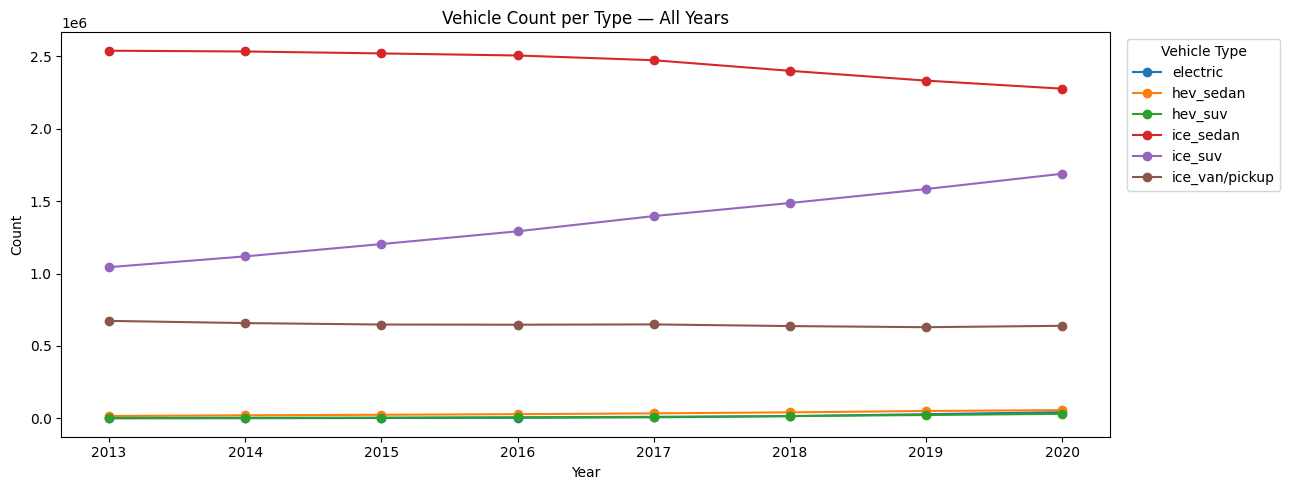

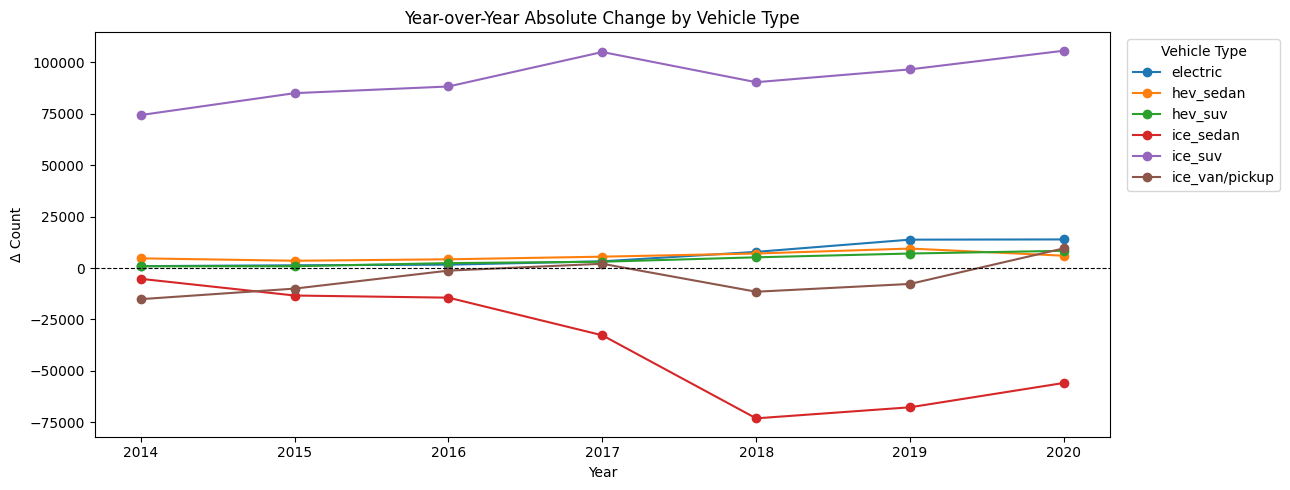

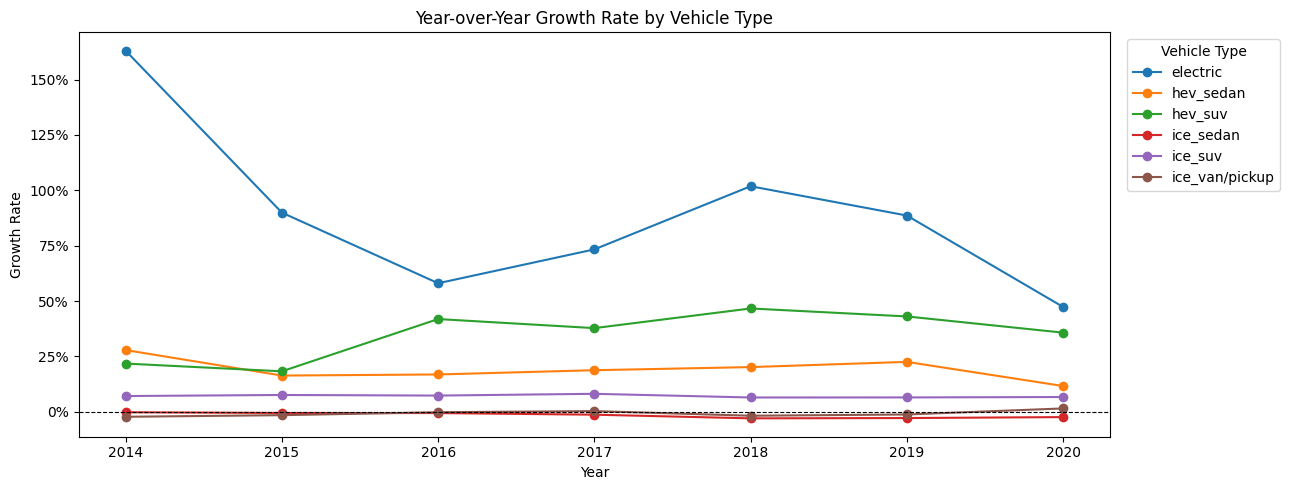


--- Market Share (%) ---
vehicle_type  electric  hev_sedan  hev_suv  ice_sedan  ice_suv  ice_van/pickup
AnneeSAAQ                                                                     
2013              0.01       0.40     0.09      59.34    24.41           15.74
2014              0.03       0.50     0.11      58.40    25.79           15.17
2015              0.06       0.57     0.13      57.20    27.32           14.71
2016              0.10       0.66     0.18      55.85    28.80           14.42
2017              0.17       0.76     0.24      54.08    30.55           14.19
2018              0.34       0.91     0.36      52.19    32.34           13.86
2019              0.63       1.11     0.50      50.16    34.06           13.54
2020              0.91       1.21     0.67      48.05    35.66           13.50


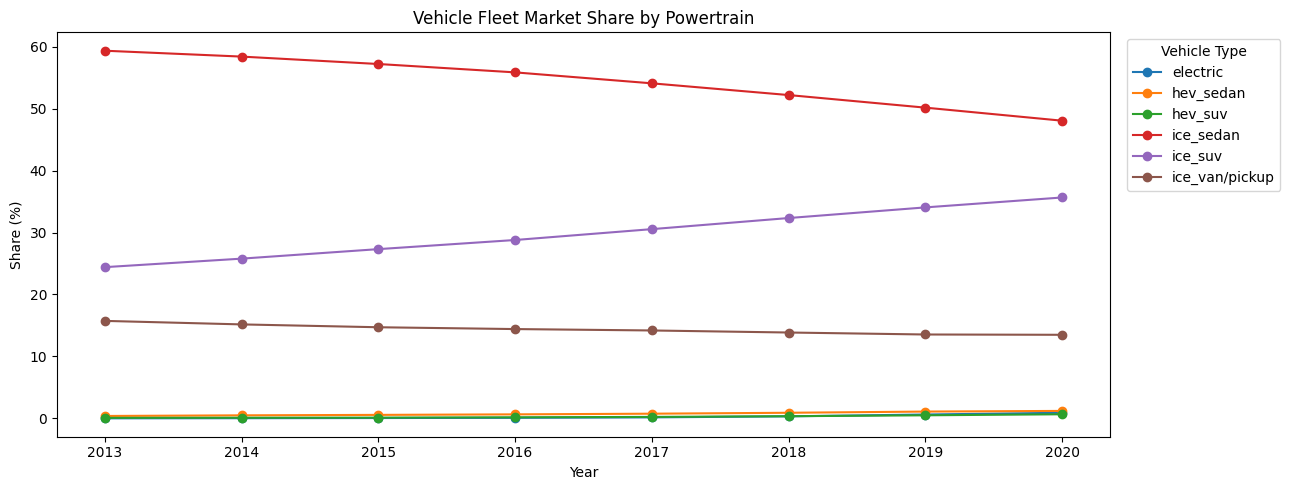

In [38]:
import os
import glob
import re
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import unicodedata

# --- 1. Helpers ---
def normalize(text):
    text = unicodedata.normalize('NFKD', str(text))
    text = text.encode('ascii', 'ignore').decode('utf-8')
    return text.lower().strip()

def get_vehicle_type(row):
    h_type = normalize(row.get('Hybrid Type', ''))
    motor  = normalize(row.get('Motorisation', ''))
    c_main = normalize(row.get('Classe principale', ''))

    is_sedan      = any(x in c_main for x in ['compacte', 'sous-compacte', 'intermediaire', 'minicompacte', 'grande berline', 'deux places'])
    is_suv        = any(x in c_main for x in ['familiale', 'fourgonnette', 'vus'])
    is_pickup_van = any(x in c_main for x in ['camionnette', 'vehicule a usage special', 'fourgon'])

    if h_type == '' and motor == '':
        return 'unknown'
    if motor == 'electrique':
        return 'electric'

    is_hybrid = (motor in ['hybride', 'hybride branchable']) or (motor == '' and h_type != '')
    is_icev   = motor in ['diesel', 'essence', 'gaz naturel']

    if is_hybrid:
        if is_suv:        return 'hev_suv'
        if is_sedan:      return 'hev_sedan'
        if is_pickup_van: return 'hev_van/pickup'
    elif is_icev:
        if is_pickup_van: return 'ice_van/pickup'
        if is_suv:        return 'ice_suv'
        if is_sedan:      return 'ice_sedan'

    return 'other'

# --- 2. Discover all CSV files in SAQ data folder ---
saq_dir = "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/SAQ data"
csv_files = sorted(glob.glob(os.path.join(saq_dir, "*.csv")))

print(f"Found {len(csv_files)} files:")
for f in csv_files:
    print(f"  {os.path.basename(f)}")

# --- 3. Load and tag each file with its year (retry on timeout) ---
COLS = ['AnneeSAAQ', 'Hybrid Type', 'Motorisation', 'Classe principale',
        'Usage', 'AgeProprio (groupes)']

def read_csv_with_retries(path, retries=3, wait_s=3):
    last_err = None
    for attempt in range(1, retries + 1):
        try:
            return pd.read_csv(path, encoding='utf-16', sep=';', low_memory=False)
        except Exception as e:
            last_err = e
            print(f"  ⚠️ Attempt {attempt}/{retries} failed for {os.path.basename(path)}: {e}")
            if attempt < retries:
                time.sleep(wait_s * attempt)
    raise last_err

frames = []
failed_files = []

for path in csv_files:
    try:
        df_raw = read_csv_with_retries(path, retries=3, wait_s=2)

        available = [c for c in COLS if c in df_raw.columns]
        df_raw = df_raw[available].copy()

        if 'AnneeSAAQ' not in df_raw.columns:
            fname = os.path.basename(path)
            year_match = re.search(r'(\d{4})', fname)
            if year_match:
                df_raw['AnneeSAAQ'] = int(year_match.group(1))

        frames.append(df_raw)
        print(f"  ✅ Loaded {os.path.basename(path)} — {len(df_raw):,} rows")

    except Exception as e:
        failed_files.append((os.path.basename(path), str(e)))
        print(f"  ❌ Skipped {os.path.basename(path)} after retries: {e}")

if not frames:
    raise RuntimeError("No CSV files could be loaded.")

all_years = pd.concat(frames, ignore_index=True)

print(f"\nTotal rows across loaded files: {len(all_years):,}")
print(f"Years found: {sorted(all_years['AnneeSAAQ'].dropna().unique().astype(int))}")

if failed_files:
    print("\nFiles that failed:")
    for f, err in failed_files:
        print(f"  - {f}: {err}")

# --- 4. Filter & classify ---
all_years = (all_years
    .query("Usage != 'Commercial' and `AgeProprio (groupes)` != 'Commercial'"
           if 'Usage' in all_years.columns and 'AgeProprio (groupes)' in all_years.columns
           else "index == index")   # no-op fallback
    .dropna(subset=['Classe principale'])
    .copy()
)

all_years['vehicle_type'] = all_years.apply(get_vehicle_type, axis=1)

all_years = all_years[
    ~all_years['vehicle_type'].isin(['unknown', 'other', 'hev_van/pickup'])
]

# --- 5. Count per year × vehicle type ---
yearly_counts = (
    all_years.groupby(['AnneeSAAQ', 'vehicle_type'])
             .size()
             .reset_index(name='count')
             .sort_values(['vehicle_type', 'AnneeSAAQ'])
)

yearly_counts['abs_change']   = yearly_counts.groupby('vehicle_type')['count'].diff()
yearly_counts['growth_rate']  = yearly_counts.groupby('vehicle_type')['count'].pct_change()

# --- 6. Summary tables ---
pivot_counts = (yearly_counts
    .pivot(index='AnneeSAAQ', columns='vehicle_type', values='count')
    .fillna(0).astype(int)
)

pivot_growth = (yearly_counts
    .pivot(index='AnneeSAAQ', columns='vehicle_type', values='growth_rate')
    .mul(100).round(1)
)

print("\n--- Vehicle Count by Year ---")
print(pivot_counts.to_string())

print("\n--- Growth Rate (%) by Year ---")
print(pivot_growth.to_string())

# --- 7. Plot: absolute counts ---
vehicle_types = yearly_counts['vehicle_type'].unique()
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(13, 5))
for i, vt in enumerate(vehicle_types):
    s = yearly_counts[yearly_counts['vehicle_type'] == vt]
    ax.plot(s['AnneeSAAQ'], s['count'], marker='o', label=vt, color=colors[i % 10])

ax.set_title('Vehicle Count per Type — All Years')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.legend(title='Vehicle Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

# --- 8. Plot: absolute year-over-year change ---
fig, ax = plt.subplots(figsize=(13, 5))
for i, vt in enumerate(vehicle_types):
    s = yearly_counts[yearly_counts['vehicle_type'] == vt].dropna(subset=['abs_change'])
    ax.plot(s['AnneeSAAQ'], s['abs_change'], marker='o', label=vt, color=colors[i % 10])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Year-over-Year Absolute Change by Vehicle Type')
ax.set_xlabel('Year')
ax.set_ylabel('Δ Count')
ax.legend(title='Vehicle Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

# --- 9. Plot: growth rate (%) ---
fig, ax = plt.subplots(figsize=(13, 5))
for i, vt in enumerate(vehicle_types):
    s = yearly_counts[yearly_counts['vehicle_type'] == vt].dropna(subset=['growth_rate'])
    ax.plot(s['AnneeSAAQ'], s['growth_rate'], marker='o', label=vt, color=colors[i % 10])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.set_title('Year-over-Year Growth Rate by Vehicle Type')
ax.set_xlabel('Year')
ax.set_ylabel('Growth Rate')
ax.legend(title='Vehicle Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show() 

# --- 10. Market share (% of fleet) ---
share = pivot_counts.div(pivot_counts.sum(axis=1), axis=0) * 100

print("\n--- Market Share (%) ---")
print(share.round(2).to_string())

fig, ax = plt.subplots(figsize=(13,5))

for i, vt in enumerate(share.columns):
    ax.plot(share.index, share[vt], marker='o', label=vt)

ax.set_title("Vehicle Fleet Market Share by Powertrain")
ax.set_xlabel("Year")
ax.set_ylabel("Share (%)")
ax.legend(title="Vehicle Type", bbox_to_anchor=(1.01,1), loc="upper left")
plt.tight_layout()
plt.show()

## 4.3 Agreggated Prevision

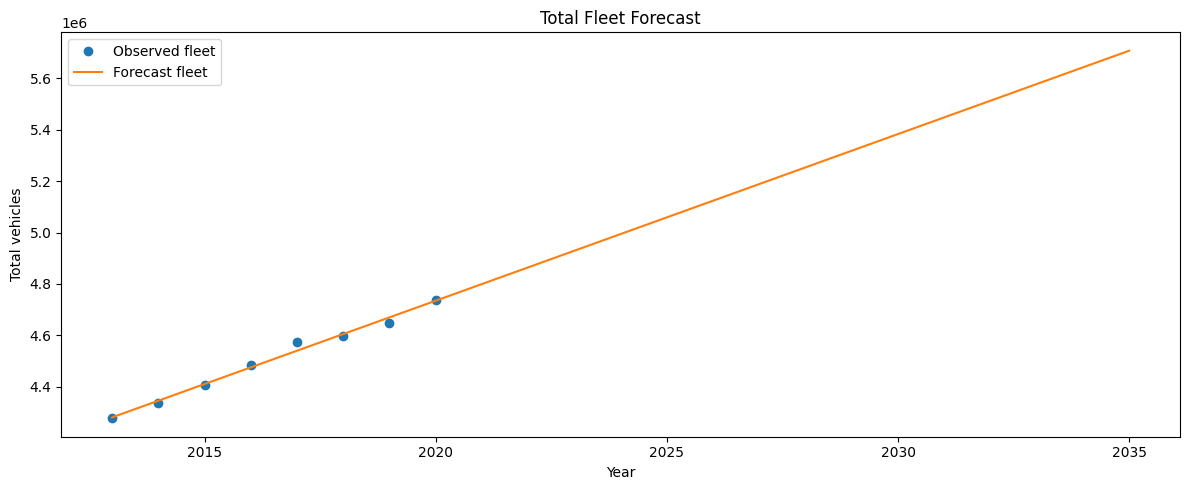

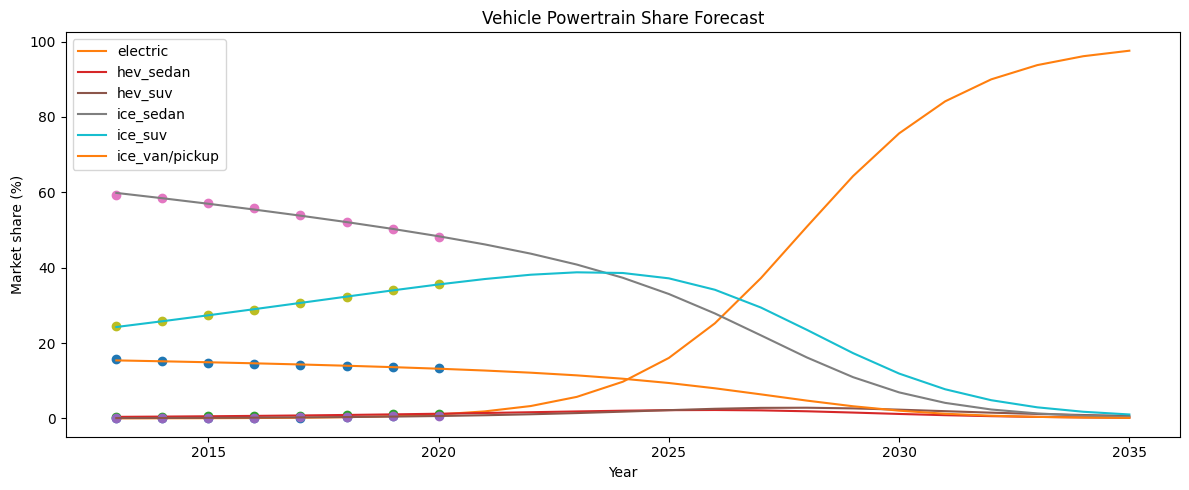

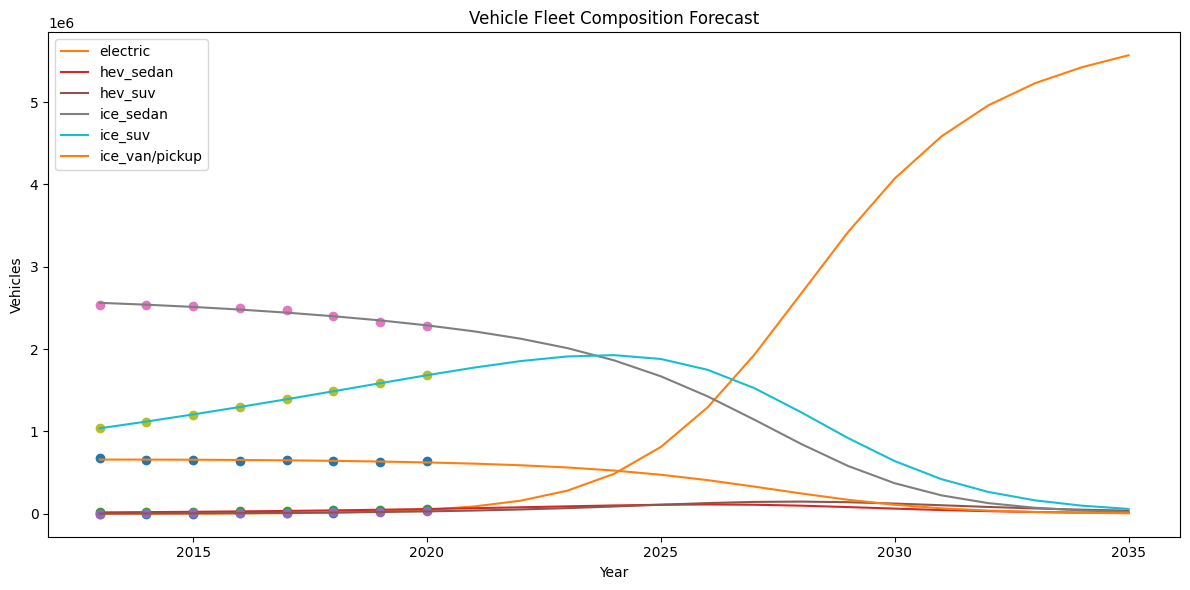


Vehicle fleet forecast:
vehicle_type  electric  hev_sedan  hev_suv  ice_sedan  ice_suv  ice_van/pickup
2013               705      17391     3439    2562599  1038425          659033
2014              1303      20839     4717    2540005  1120759          658738
2015              2404      24922     6457    2512828  1207323          657193
2016              4426      29745     8822    2480758  1297861          654285
2017              8128      35416    12023    2443335  1391906          649856
2018             14885      42053    16342    2399832  1488645          643676
2019             27169      49763    22136    2349071  1586681          635382
2020             49367      58623    29851    2289115  1683620          624393
2021             89144      68632    40004    2216812  1775368          609778
2022            159502      79615    53120    2127185  1855018          590065
2023            281427      91074    69557    2012834  1911322          563060
2024            485944     

In [39]:
# ============================================================
# MULTI-TECHNOLOGY VEHICLE ADOPTION FORECAST
# Forecast all vehicle types simultaneously
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

vehicle_types = pivot_counts.columns
years = pivot_counts.index.values

fleet = pivot_counts.sum(axis=1)

# market shares
shares = pivot_counts.div(fleet, axis=0)

# ------------------------------------------------------------
# 2. Forecast total fleet growth
# ------------------------------------------------------------

X = years.reshape(-1,1)
fleet_model = LinearRegression()
fleet_model.fit(X, fleet.values)

future_years = np.arange(years.min(), 2036)

fleet_future = fleet_model.predict(future_years.reshape(-1,1))

# ------------------------------------------------------------
# 3. Multinomial logit transformation
# log(share_i / share_base)
# ------------------------------------------------------------

base_vehicle = vehicle_types[0]

log_ratios = {}

for vt in vehicle_types:
    if vt != base_vehicle:
        log_ratios[vt] = np.log(shares[vt] / shares[base_vehicle])

# ------------------------------------------------------------
# 4. Fit regression for each technology share
# ------------------------------------------------------------

models = {}

for vt, series in log_ratios.items():

    y = series.values
    model = LinearRegression()
    model.fit(X, y)

    models[vt] = model

# ------------------------------------------------------------
# 5. Predict future shares
# ------------------------------------------------------------

log_ratio_pred = {}

for vt, model in models.items():
    log_ratio_pred[vt] = model.predict(future_years.reshape(-1,1))

log_ratio_pred = pd.DataFrame(log_ratio_pred, index=future_years)

# convert log-ratios back to shares
shares_future = pd.DataFrame(index=future_years, columns=vehicle_types)

shares_future[base_vehicle] = 1

for vt in models.keys():
    shares_future[vt] = np.exp(log_ratio_pred[vt])

shares_future = shares_future.div(shares_future.sum(axis=1), axis=0)

# ------------------------------------------------------------
# 6. Convert shares to vehicle counts
# ------------------------------------------------------------

counts_future = shares_future.multiply(fleet_future, axis=0)

# ------------------------------------------------------------
# 7. Plot fleet forecast
# ------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(years, fleet, 'o', label="Observed fleet")
plt.plot(future_years, fleet_future, label="Forecast fleet")

plt.xlabel("Year")
plt.ylabel("Total vehicles")
plt.title("Total Fleet Forecast")

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Plot market share evolution
# ------------------------------------------------------------

plt.figure(figsize=(12,5))

for vt in vehicle_types:
    plt.plot(years, shares[vt]*100, 'o')
    plt.plot(future_years, shares_future[vt]*100, label=vt)

plt.xlabel("Year")
plt.ylabel("Market share (%)")
plt.title("Vehicle Powertrain Share Forecast")

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Plot vehicle counts by technology
# ------------------------------------------------------------

plt.figure(figsize=(12,6))

for vt in vehicle_types:
    plt.plot(years, pivot_counts[vt], 'o')
    plt.plot(future_years, counts_future[vt], label=vt)

plt.xlabel("Year")
plt.ylabel("Vehicles")
plt.title("Vehicle Fleet Composition Forecast")

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Output forecast tables
# ------------------------------------------------------------

forecast_table = counts_future.round(0).astype(int)

print("\nVehicle fleet forecast:")
print(forecast_table.head(20))

## 4.4 Build training data from ALL SAQ CSVs + train year-based car-share model


In [16]:
import os
import re
import glob
import unicodedata
import pandas as pd
from tqdm import tqdm

saq_dir = "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/SAQ data"
csv_files = sorted(glob.glob(os.path.join(saq_dir, "*.csv")))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {saq_dir}")

def normalize(text):
    text = unicodedata.normalize("NFKD", str(text))
    text = text.encode("ascii", "ignore").decode("utf-8")
    return text.lower().strip()

def get_vehicle_type(row):
    h_type = normalize(row.get("Hybrid Type", ""))
    motor  = normalize(row.get("Motorisation", ""))
    c_main = normalize(row.get("Classe principale", ""))

    is_sedan      = any(x in c_main for x in ["compacte", "sous-compacte", "intermediaire", "minicompacte", "grande berline", "deux places"])
    is_suv        = any(x in c_main for x in ["familiale", "fourgonnette", "vus"])
    is_pickup_van = any(x in c_main for x in ["camionnette", "vehicule a usage special", "fourgon"])

    if motor == "electrique":
        return "electric"

    is_hybrid = (motor in ["hybride", "hybride branchable"]) or (motor == "" and h_type != "")
    is_icev   = motor in ["diesel", "essence", "gaz naturel"]

    if is_hybrid:
        if is_suv:        return "hev_suv"
        if is_sedan:      return "hev_sedan"
        if is_pickup_van: return "hev_van/pickup"
    if is_icev:
        if is_pickup_van: return "ice_van/pickup"
        if is_suv:        return "ice_suv"
        if is_sedan:      return "ice_sedan"

    return "other"

needed = ["RTA", "Genre", "AgeProprio (groupes)", "AnneeSAAQ", "Hybrid Type", "Motorisation", "Classe principale", "Usage"]
frames = []

for path in tqdm(csv_files, desc="Loading SAQ CSV files", unit="file"):
    d = pd.read_csv(path, encoding="utf-16", sep=";", low_memory=False)

    # recover year from filename if missing
    if "AnneeSAAQ" not in d.columns:
        m = re.search(r"(20\d{2}|19\d{2})", os.path.basename(path))
        if m:
            d["AnneeSAAQ"] = int(m.group(1))

    present = [c for c in needed if c in d.columns]
    if {"RTA", "Genre", "AgeProprio (groupes)", "AnneeSAAQ", "Classe principale"}.issubset(set(present)):
        frames.append(d[present].copy())


if not frames:
    raise RuntimeError("No usable CSVs with required columns were found.")

all_df = pd.concat(frames, ignore_index=True)

df_model = (
    all_df.rename(columns={"RTA": "fsa", "Genre": "gender", "AgeProprio (groupes)": "age_group"})
          .query("Usage != 'Commercial' and age_group != 'Commercial'" if "Usage" in all_df.columns else "index == index")
          .dropna(subset=["fsa", "gender", "age_group", "AnneeSAAQ", "Classe principale"])
          .copy()
)

df_model["fsa"] = df_model["fsa"].astype(str).str.upper().str.strip()
df_model["gender"] = df_model["gender"].astype(str).str.strip()
df_model["age_group"] = df_model["age_group"].astype(str).str.strip()
df_model["AnneeSAAQ"] = pd.to_numeric(df_model["AnneeSAAQ"], errors="coerce")
df_model = df_model.dropna(subset=["AnneeSAAQ"])
df_model["AnneeSAAQ"] = df_model["AnneeSAAQ"].astype(int)

tqdm.pandas(desc="Classifying vehicle types")
df_model["vehicle_type"] = df_model.progress_apply(get_vehicle_type, axis=1)
df_model = df_model[~df_model["vehicle_type"].isin(["other", "hev_van/pickup"])]
print("\nSample of classified data:")
print(df_model[["fsa", "gender", "age_group", "vehicle_type"]].head())

Classifying vehicle types: 100%|██████████| 36048405/36048405 [07:28<00:00, 80364.49it/s]



Sample of classified data:
     fsa gender    age_group vehicle_type
208  H3M      F  50 à 59 ans    ice_sedan
209  H4M      F  40 à 49 ans    ice_sedan
210  H4N      F  50 à 59 ans    ice_sedan
211  H3M      F  50 à 59 ans    ice_sedan
212  H4C      F  40 à 49 ans    ice_sedan


In [17]:
df_model

,fsa,gender,age_group,AnneeSAAQ,Hybrid Type,Motorisation,Classe principale,Usage,vehicle_type
208,H3M,F,50 à 59 ans,2013,NaN,Essence,Compacte,Personnel,ice_sedan
209,H4M,F,40 à 49 ans,2013,NaN,Essence,Compacte,Personnel,ice_sedan
210,H4N,F,50 à 59 ans,2013,NaN,Essence,Compacte,Personnel,ice_sedan
211,H3M,F,50 à 59 ans,2013,NaN,Essence,Compacte,Personnel,ice_sedan
212,H4C,F,40 à 49 ans,2013,NaN,Essence,Compacte,Personnel,ice_sedan
...,...,...,...,...,...,...,...,...,...
41798956,G0M,H,40 à 49 ans,2020,NaN,Essence,Camionnette,Personnel,ice_van/pickup
41798958,J8R,H,50 à 59 ans,2020,NaN,Essence,Camionnette,Personnel,ice_van/pickup
41798959,J0K,H,40 à 49 ans,2020,NaN,Essence,Camionnette,Personnel,ice_van/pickup
41799001,J0H,H,50 à 59 ans,2020,NaN,Essence,Camionnette,Personnel,ice_van/pickup


In [25]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier


# ============================================================
# SETTINGS
# ============================================================

USE_SAMPLE = False
SAMPLE_SIZE = 200_000
TEST_SIZE = 0.2


# ============================================================
# DATA PREPARATION
# ============================================================

print("\nPreparing dataset...")

if USE_SAMPLE:
    df_train = df_model.sample(n=SAMPLE_SIZE, random_state=42)
else:
    df_train = df_model.copy()


# ============================================================
# FAST CATEGORY ENCODING
# ============================================================

print("\nEncoding categorical variables...")

df_train["fsa_code"] = df_train["fsa"].astype("category").cat.codes
df_train["gender_code"] = df_train["gender"].astype("category").cat.codes
df_train["age_code"] = df_train["age_group"].astype("category").cat.codes
df_train["vehicle_code"] = df_train["vehicle_type"].astype("category").cat.codes

vehicle_labels = dict(
    enumerate(df_train["vehicle_type"].astype("category").cat.categories)
)


# ============================================================
# FEATURES
# ============================================================

features = ["fsa_code","gender_code","age_code","AnneeSAAQ"]

X = df_train[features]
y = df_train["vehicle_code"]


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

print("\nSplitting dataset...")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=42
)


# ============================================================
# MODELS
# ============================================================

models = {

    "logistic":
    LogisticRegression(
        max_iter=2000,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "random_forest":
    RandomForestClassifier(
        n_estimators=200,
        max_depth=25,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "hist_gradient_boosting":
    HistGradientBoostingClassifier(
        max_iter=250
    )
}


# ============================================================
# TRAINING
# ============================================================

trained_models = {}
results = {}

print("\nTraining models...")

for name,model in tqdm(models.items(),desc="Training models"):

    model.fit(X_train,y_train)

    trained_models[name] = model


# ============================================================
# EVALUATION
# ============================================================

print("\nEvaluating models...")

for name,model in tqdm(trained_models.items(),desc="Evaluating"):

    preds = model.predict(X_test)

    acc = accuracy_score(y_test,preds)

    print("\n========================")
    print("Model:",name)
    print("Accuracy:",round(acc,3))

    print(
        classification_report(
            y_test,
            preds,
            zero_division=0
        )
    )

    results[name] = acc


# ============================================================
# BEST MODEL
# ============================================================

best_model_name = max(results,key=results.get)

print("\nBest model:",best_model_name)

best_model = trained_models[best_model_name]


# ============================================================
# FUTURE PREDICTION EXAMPLE
# ============================================================

example = pd.DataFrame({

    "fsa_code":[df_train["fsa_code"].iloc[0]],
    "gender_code":[df_train["gender_code"].iloc[0]],
    "age_code":[df_train["age_code"].iloc[0]],
    "AnneeSAAQ":[2030]

})

prediction = best_model.predict(example)[0]

print("\nPredicted vehicle type:",vehicle_labels[prediction])


Preparing dataset...

Encoding categorical variables...

Splitting dataset...

Training models...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]/Users/natomanzolli/opt/anaconda3/envs/bus_charging_app/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Training models: 100%|██████████| 3/3 [11:33:05<00:00, 13861.79s/it]  



Evaluating models...


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]


Model: logistic
Accuracy: 0.249


...

              precision    recall  f1-score   support

           0       0.00      0.30      0.01     21152
           1       0.01      0.16      0.02     55688
           2       0.00      0.04      0.01     21188
           3       0.61      0.31      0.41   3911499
           4       0.25      0.04      0.06   2161037
           5       0.20      0.45      0.28   1035542

    accuracy                           0.25   7206106
   macro avg       0.18      0.22      0.13   7206106
weighted avg       0.44      0.25      0.28   7206106


Model: random_forest
Accuracy: 0.292


Evaluating:  67%|██████▋   | 2/3 [01:21<00:45, 45.91s/it]

              precision    recall  f1-score   support

           0       0.01      0.53      0.02     21152
           1       0.01      0.16      0.02     55688
           2       0.01      0.28      0.01     21188
           3       0.70      0.36      0.47   3911499
           4       0.36      0.10      0.16   2161037
           5       0.27      0.45      0.34   1035542

    accuracy                           0.29   7206106
   macro avg       0.23      0.31      0.17   7206106
weighted avg       0.53      0.29      0.35   7206106


Model: hist_gradient_boosting
Accuracy: 0.549


Evaluating: 100%|██████████| 3/3 [02:17<00:00, 45.77s/it]

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     21152
           1       0.00      0.00      0.00     55688
           2       0.00      0.00      0.00     21188
           3       0.56      0.94      0.70   3911499
           4       0.42      0.08      0.14   2161037
           5       0.41      0.10      0.16   1035542

    accuracy                           0.55   7206106
   macro avg       0.23      0.19      0.17   7206106
weighted avg       0.49      0.55      0.45   7206106


Best model: hist_gradient_boosting

Predicted vehicle type: ice_sedan


In [28]:
import joblib
model_path = "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/car_share_model_best.joblib"

# Save (run once after training)
joblib.dump(best_model, model_path)
print(f"Model saved to: {model_path}")

Model saved to: /Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/car_share_model_best.joblib


In [ ]:
import os
import joblib

# Load (in future sessions)
#model_path = "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/car_share_model_best.joblib"

if os.path.exists(model_path):
    car_share_model = joblib.load(model_path)
    print("Loaded existing trained model.")
else:
    print("Model file not found. Train first, then save with joblib.dump(...).")

In [34]:
from pathlib import Path

# ============================================================
# BULK PREDICTION FOR A SELECTED YEAR (ALL FSA x AGE x VEHICLE)
# ============================================================

target_year = 2021
aggregate_over_gender = True

# 1) Build lookup tables from encoded training data
fsa_map = df_train[["fsa_code", "fsa"]].drop_duplicates().sort_values("fsa_code")
gender_map = df_train[["gender_code", "gender"]].drop_duplicates().sort_values("gender_code")
age_map = df_train[["age_code", "age_group"]].drop_duplicates().sort_values("age_code")

# 2) Cartesian product of all category codes
grid = (
    fsa_map[["fsa_code"]].assign(key=1)
    .merge(gender_map[["gender_code"]].assign(key=1), on="key")
    .merge(age_map[["age_code"]].assign(key=1), on="key")
    .drop(columns="key")
)

grid["AnneeSAAQ"] = target_year

# 3) Predict probabilities (share-like output)
X_pred = grid[["fsa_code", "gender_code", "age_code", "AnneeSAAQ"]]
proba = best_model.predict_proba(X_pred)

# Map model class ids -> vehicle type labels
class_ids = best_model.classes_
class_names = [vehicle_labels[int(c)] for c in class_ids]

proba_df = pd.DataFrame(proba, columns=class_names)
pred_long = pd.concat([grid.reset_index(drop=True), proba_df], axis=1).melt(
    id_vars=["fsa_code", "gender_code", "age_code", "AnneeSAAQ"],
    var_name="vehicle_type",
    value_name="predicted_share"
)

# 4) Add readable labels
pred_long = (
    pred_long
    .merge(fsa_map, on="fsa_code", how="left")
    .merge(gender_map, on="gender_code", how="left")
    .merge(age_map, on="age_code", how="left")
)

pred_long["predicted_share_pct"] = pred_long["predicted_share"] * 100.0

# 5) Optional aggregation across gender
if aggregate_over_gender:
    out = (
        pred_long.groupby(["fsa", "age_group", "AnneeSAAQ", "vehicle_type"], as_index=False)["predicted_share"]
        .mean()
    )
    denom = out.groupby(["fsa", "age_group", "AnneeSAAQ"])["predicted_share"].transform("sum")
    out["predicted_share"] = np.where(denom > 0, out["predicted_share"] / denom, 0.0)
    out["predicted_share_pct"] = out["predicted_share"] * 100.0
    out = out.sort_values(["fsa", "age_group", "vehicle_type"]).reset_index(drop=True)
else:
    out = pred_long[[
        "fsa", "gender", "age_group", "AnneeSAAQ", "vehicle_type", "predicted_share", "predicted_share_pct"
    ]].sort_values(["fsa", "gender", "age_group", "vehicle_type"]).reset_index(drop=True)

# 6) Save CSV
out_path = Path(
    f"/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/"
    f"adoption prediction model/predicted_car_share_{target_year}_all_fsa_age_vehicle.csv"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
out.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
display(out.head(10))

Saved: /Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/predicted_car_share_2021_all_fsa_age_vehicle.csv


,fsa,age_group,AnneeSAAQ,vehicle_type,predicted_share,predicted_share_pct
0,G0A,19 ans et moins,2021,electric,0.000244,0.024408
1,G0A,19 ans et moins,2021,hev_sedan,0.001411,0.141115
2,G0A,19 ans et moins,2021,hev_suv,0.000018,0.001761
3,G0A,19 ans et moins,2021,ice_sedan,0.806775,80.677520
4,G0A,19 ans et moins,2021,ice_suv,0.112836,11.283623
5,G0A,19 ans et moins,2021,ice_van/pickup,0.078716,7.871572
6,G0A,20 à 29 ans,2021,electric,0.002385,0.238492
7,G0A,20 à 29 ans,2021,hev_sedan,0.003744,0.374361
8,G0A,20 à 29 ans,2021,hev_suv,0.002184,0.218448
9,G0A,20 à 29 ans,2021,ice_sedan,0.574481,57.448074


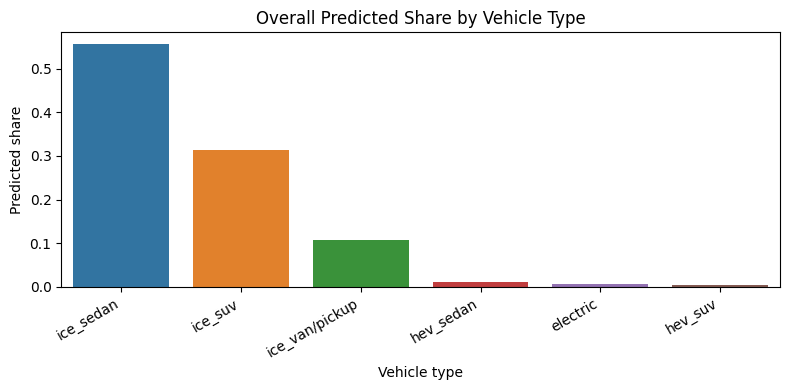

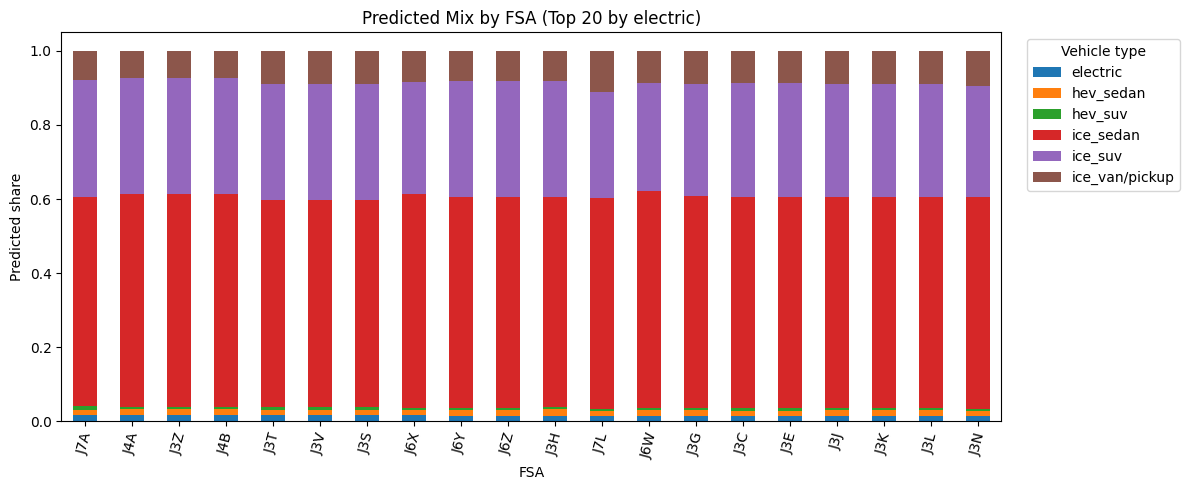

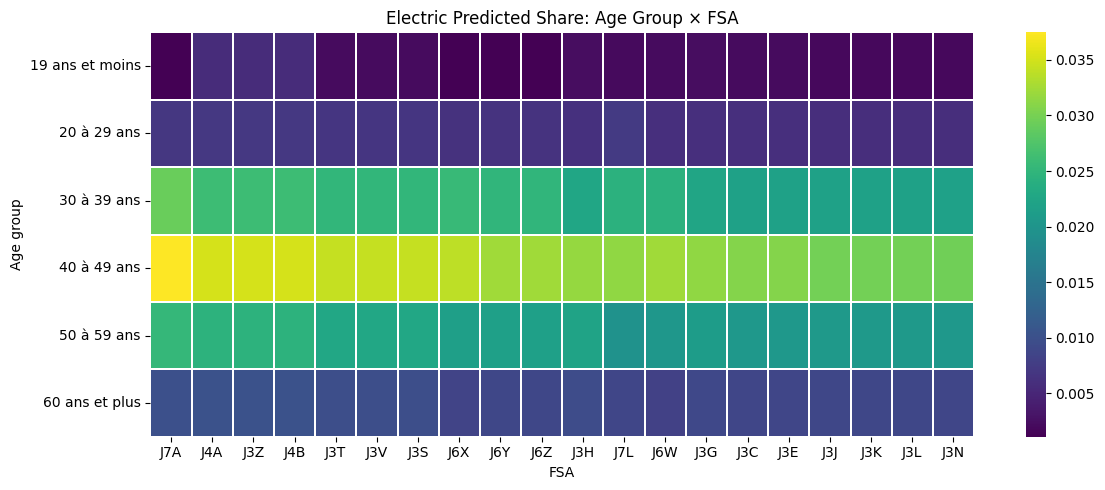

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_prediction_results(
    pred_df: pd.DataFrame,
    top_n_fsas: int = 20,
    highlight_vehicle: str = "electric"
):
    """
    Expects columns:
    fsa, age_group, AnneeSAAQ, vehicle_type, predicted_share
    (gender can exist, it will be aggregated out)
    """
    required = {"fsa", "age_group", "AnneeSAAQ", "vehicle_type", "predicted_share"}
    missing = required - set(pred_df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # Normalize schema (aggregate if gender exists)
    dfp = pred_df.copy()
    group_cols = ["fsa", "age_group", "AnneeSAAQ", "vehicle_type"]
    dfp = dfp.groupby(group_cols, as_index=False)["predicted_share"].mean()

    # ---------------------------
    # 1) Overall vehicle-type share
    # ---------------------------
    overall = (
        dfp.groupby("vehicle_type", as_index=False)["predicted_share"]
           .mean()
           .sort_values("predicted_share", ascending=False)
    )

    plt.figure(figsize=(8, 4))
    sns.barplot(data=overall, x="vehicle_type", y="predicted_share")
    plt.title("Overall Predicted Share by Vehicle Type")
    plt.ylabel("Predicted share")
    plt.xlabel("Vehicle type")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    # ---------------------------
    # 2) Stacked bars by FSA (top N by highlighted vehicle)
    # ---------------------------
    hl = dfp[dfp["vehicle_type"] == highlight_vehicle]
    top_fsas = (
        hl.groupby("fsa", as_index=False)["predicted_share"]
          .mean()
          .sort_values("predicted_share", ascending=False)
          .head(top_n_fsas)["fsa"]
          .tolist()
    )

    fsa_mix = (
        dfp[dfp["fsa"].isin(top_fsas)]
        .groupby(["fsa", "vehicle_type"], as_index=False)["predicted_share"]
        .mean()
        .pivot(index="fsa", columns="vehicle_type", values="predicted_share")
        .fillna(0)
    )

    fsa_mix = fsa_mix.loc[top_fsas]  # keep ranking order
    fsa_mix.plot(kind="bar", stacked=True, figsize=(12, 5))
    plt.title(f"Predicted Mix by FSA (Top {top_n_fsas} by {highlight_vehicle})")
    plt.ylabel("Predicted share")
    plt.xlabel("FSA")
    plt.xticks(rotation=75)
    plt.legend(title="Vehicle type", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # ---------------------------
    # 3) Heatmap: highlighted vehicle by age_group x top FSA
    # ---------------------------
    heat = (
        dfp[dfp["vehicle_type"] == highlight_vehicle]
        .pivot_table(index="age_group", columns="fsa", values="predicted_share", aggfunc="mean")
        .reindex(columns=top_fsas)
    )

    plt.figure(figsize=(12, 5))
    sns.heatmap(heat, cmap="viridis", linewidths=0.2)
    plt.title(f"{highlight_vehicle.capitalize()} Predicted Share: Age Group × FSA")
    plt.xlabel("FSA")
    plt.ylabel("Age group")
    plt.tight_layout()
    plt.show()

# Run
plot_prediction_results(out, top_n_fsas=20, highlight_vehicle="electric")